# Comparación del parámetro `invert_order` en `TravelTimeMatrices`

El siguiente _notebook_ es una comparación del parámetro `invert_order` en
`TravelTimeMatrices.compute()`, observando el cambio en el tiempo de
computación y en la calidad de los resultados al variar el parámetro.

Se utilizará el área urbana de Santiago para obtener los orígenes; los destinos
serán farmacias (para el caso de caminata) o hospitales/clínicas (para el caso
de transporte público) dentro de la envoltura convexa.

In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import datetime
from time import time
from pathlib import Path

import geopandas as gpd
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import matplotlib.colors as mcolors

import xmin
from xmin.dataset import extract_osm_subset
from xmin.indices import EnhancedTwoStepFca, TwoStepFca
from xmin import travel_time

In [3]:
RAW_DATA_PATH = Path("../../data/raw")  # datos no procesados
PRE_DATA_PATH = Path("../../data/processed")  # datos preprocesados
IMG_PATH = Path("../../reports/figures")
xmin.config.quackosm_working_directory = Path("../../data/interim/quackosm")

In [4]:
OSM_CHILE_PATH = RAW_DATA_PATH / "osm" / "Chile.osm.pbf"

CENSO_PATH = PRE_DATA_PATH / "censo" / "Cartografia.gpkg"
AMENITY_SALUD_PATH = PRE_DATA_PATH / "amenities" / "salud.gpkg"
OSM_SANTIAGO_PATH = PRE_DATA_PATH / "osm" / "Santiago.osm.pbf"
GTFS_SANTIAGO_PATH = PRE_DATA_PATH / "gtfs" / "Santiago.zip"

## Orígenes y destinos

In [5]:
# carga de datos
limites_urbanos_full = gpd.read_file(
    CENSO_PATH,
    layer="Limite_Urbano_CPV24",
)

# filtramos solo las áreas de interés
limites_urbanos = limites_urbanos_full[
    (limites_urbanos_full["LOCALIDAD"] == "GRAN SANTIAGO")
]

# obtenemos envoltura convexa para extraer POIs y red vial
limites_envoltura = limites_urbanos.union_all().convex_hull

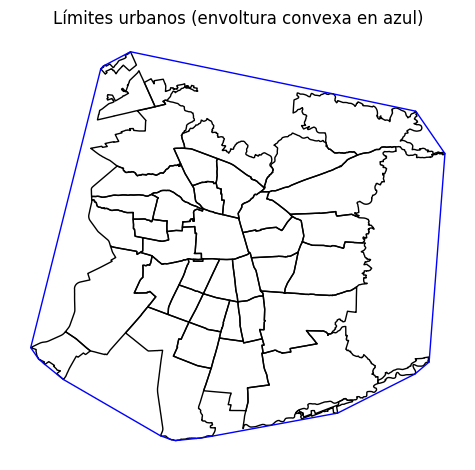

In [6]:
ax = limites_urbanos.plot(facecolor="none", edgecolor="black")
gpd.GeoSeries([limites_envoltura]).plot(
    ax=ax, facecolor="none", edgecolor="blue"
)
ax.set_axis_off()
plt.title("Límites urbanos (envoltura convexa en azul)")
plt.tight_layout()

In [7]:
manzanas = gpd.read_file(
    CENSO_PATH,
    layer="Manzanas_CPV24",
    mask=limites_urbanos.union_all(),
    use_arrow=True
)

In [8]:
origins = xmin.Origins.create_grid(
    regions=limites_urbanos,
    h3_resolution=9
)

In [9]:
if not OSM_SANTIAGO_PATH.exists():
    extract_osm_subset(
        OSM_CHILE_PATH,
        OSM_SANTIAGO_PATH,
        bounds=limites_envoltura
    )

In [52]:
farmacias = xmin.Amenity.from_osm(
    name="farmacias",
    osm_path=OSM_SANTIAGO_PATH,
    osm_filter={"amenity": ["pharmacy"]},
    keep_all_tags=["name"]
)
len(farmacias.amenity_gdf)

1141

In [53]:
salud_gdf = gpd.read_file(AMENITY_SALUD_PATH, mask=limites_envoltura)

salud = xmin.Amenity(
    name="salud",
    amenity_gdf=salud_gdf[salud_gdf["TIPO"].isin(["Hospital", "Clínica"])]
)
len(salud.amenity_gdf)

118

## Cálculo de TTMs

In [45]:
t0 = time()
ttm_walk_normal = xmin.TravelTimeMatrices.compute(
    origins=origins,
    amenities=[farmacias],
    gtfs_paths=[],
    osm_path=OSM_SANTIAGO_PATH,
    snap_to_network=True,
    max_time=datetime.timedelta(minutes=30),
    transport_modes=["WALK"],
    invert_order=False,
)
t1 = time()
print(f"Tiempo de ejecución: {t1 - t0}s.")

Calculando tiempos de viaje desde cada origen...


  0%|          | 0/9025 [00:00<?, ?it/s]

Tiempo de ejecución: 117.946946144104s.


In [46]:
t0 = time()
ttm_walk_invert = xmin.TravelTimeMatrices.compute(
    origins=origins,
    amenities=[farmacias],
    gtfs_paths=[],
    osm_path=OSM_SANTIAGO_PATH,
    snap_to_network=True,
    max_time=datetime.timedelta(minutes=30),
    transport_modes=["WALK"],
    invert_order=True,
)
t1 = time()
print(f"Tiempo de ejecución: {t1 - t0}s.")

Calculando tiempos de viaje desde cada destino...


  0%|          | 0/1141 [00:00<?, ?it/s]

Tiempo de ejecución: 64.48549795150757s.


In [12]:
t0 = time()
ttm_transit_normal = xmin.TravelTimeMatrices.compute(
    origins=origins,
    amenities=[salud],
    gtfs_paths=GTFS_SANTIAGO_PATH,
    osm_path=OSM_SANTIAGO_PATH,
    snap_to_network=True,
    max_time=datetime.timedelta(minutes=60),
    transport_modes=["WALK", "TRANSIT"],
    invert_order=False,
)
t1 = time()
print(f"Tiempo de ejecución: {t1 - t0}s.")

Calculando tiempos de viaje desde cada origen...


  0%|          | 0/9025 [00:00<?, ?it/s]

Tiempo de ejecución: 618.8789963722229s.


In [13]:
t0 = time()
ttm_transit_invert = xmin.TravelTimeMatrices.compute(
    origins=origins,
    amenities=[salud],
    gtfs_paths=GTFS_SANTIAGO_PATH,
    osm_path=OSM_SANTIAGO_PATH,
    snap_to_network=True,
    max_time=datetime.timedelta(minutes=60),
    transport_modes=["WALK", "TRANSIT"],
    invert_order=True,
)
t1 = time()
print(f"Tiempo de ejecución: {t1 - t0}s.")

Calculando tiempos de viaje desde cada destino...


  0%|          | 0/118 [00:00<?, ?it/s]

Tiempo de ejecución: 27.195870637893677s.


## Comparación de resultados

In [47]:
ttm_walk_comp = ttm_walk_normal.matrices["farmacias"].merge(
    ttm_walk_invert.matrices["farmacias"],
    on=["from_id", "to_id"],
    how="outer",
    suffixes=("_normal", "_invert")
)

ttm_transit_comp = ttm_transit_normal.matrices["salud"].merge(
    ttm_transit_invert.matrices["salud"],
    on=["from_id", "to_id"],
    how="outer",
    suffixes=("_normal", "_invert")
)

Se observa que la cantidad de viajes "perdidos" al invertir el sentido (viajes
que antes se lograban realizar por debajo del umbral, pero ahora no) es
relativamente baja. Sin embargo, la distribución de estos viajes perdidos no es
uniforme: zonas como Valle Lo Campino en Quilicura pierden hasta un 100% de sus
viajes.

In [48]:
print("porcentaje de viajes perdidos:")
for ttm_comp, name in zip(
    (ttm_walk_comp, ttm_transit_comp), ("walk", "transit")
):
    ttm_comp["missed"] = (
        ttm_comp["travel_time_normal"].notna()
        & ttm_comp["travel_time_invert"].isna()
    )
    ttm_comp["diff"] = (
        ttm_comp["travel_time_normal"]
        - ttm_comp["travel_time_invert"]
    )
    
    print(f"{name}: ", end="")
    print(
        ttm_comp["missed"].sum()
        / ttm_comp["travel_time_normal"].notna().sum()
    )

porcentaje de viajes perdidos:
walk: 0.014549474567010178
transit: 0.05698569518133212


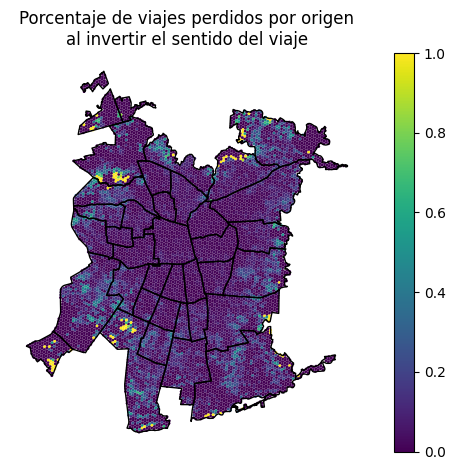

In [56]:
missed_by_origin = origins.h3_grid.set_index("id").assign(
    missed=ttm_transit_comp.groupby("from_id")["missed"].mean()
).fillna(0)

ax = missed_by_origin.plot("missed", legend=True)
limites_urbanos.plot(ax=ax, facecolor="none", edgecolor="black")
ax.set_axis_off()
plt.title(
    "Porcentaje de viajes perdidos por origen\n"
    "al invertir el sentido del viaje"
)
plt.tight_layout()
plt.savefig(IMG_PATH / "lost_trips.pdf")

Se observa que los tiempos de viaje en caminata son prácticamente iguales, por
lo cual sería recomendable activar esta opción en el caso de que sea el único
modo de transporte utilizado (y la cantidad de destinos no supere a la cantidad
de orígenes). Para el transporte público existe una mayor diferencia al cambiar
de sentido, aunque las ganancias en tiempo de cómputo son mayores. Por ende, se
dejará a discreción del usuario la decisión de invertir el sentido del viaje
cuando lo considere apropiado.

In [49]:
ttm_walk_comp["diff"].describe()

count    77552.000000
mean         0.000039
std          0.041723
min         -4.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          4.000000
Name: diff, dtype: float64

In [44]:
ttm_transit_comp["diff"].describe()

count    367388.000000
mean         -0.007834
std           2.700459
min         -19.000000
25%          -2.000000
50%           0.000000
75%           2.000000
max          17.000000
Name: diff, dtype: float64

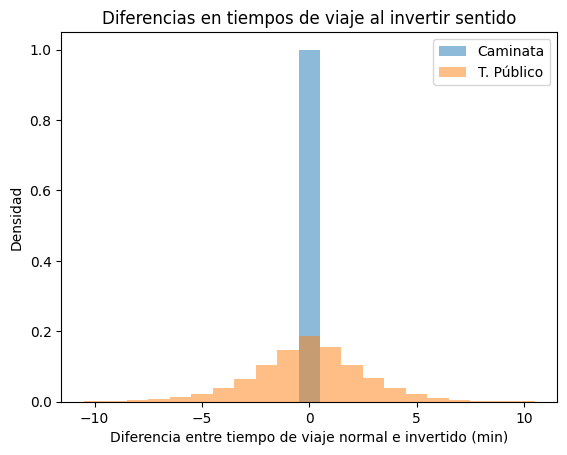

In [55]:
bins = np.arange(-10.5, 11, 1)
ax = ttm_walk_comp["diff"].rename("Caminata").plot.hist(
    density=True, bins=bins, alpha=0.5
)
ttm_transit_comp["diff"].rename("T. Público").plot.hist(
    density=True, ax=ax, bins=bins, alpha=0.5
)

ax.set_xlabel("Diferencia entre tiempo de viaje normal e invertido (min)")
ax.set_ylabel("Densidad")
plt.title("Diferencias en tiempos de viaje al invertir sentido")
plt.legend()
plt.savefig(IMG_PATH / "ttm_invert_comparison.pdf")